Personal Project

Honing my deep learning skills by building a plant disease image classification site, using Computer Vision.

In [ ]:
import tensorflow as tf   #importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import cv2

print("Tensorflow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Tensorflow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")    #getting the dataset
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [ ]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 1:
        break

plantvillage-dataset/
  plantvillage dataset/


In [ ]:
dataset_path = os.path.join(path, "plantvillage dataset")
for folder in os.listdir(dataset_path):
    print(folder)

segmented
grayscale
color


In [ ]:
dataset_path = os.path.join(path, "plantvillage dataset", "color")
classes = os.listdir(dataset_path)
classes.sort()

print(f"Total classes: {len(classes)}")
print("\nClasses:")
for i, cls in enumerate(classes):
    print(f"{i+1}. {cls}")

Total classes: 38

Classes:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spid

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#count images per class
print("Images per class:")
total_images = 0
for cls in sorted(classes):
    cls_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(cls_path))
    total_images += count
    print(f"  {cls}: {count} images")

print(f"\nTotal images: {total_images}")

Images per class:
  Apple___Apple_scab: 630 images
  Apple___Black_rot: 621 images
  Apple___Cedar_apple_rust: 275 images
  Apple___healthy: 1645 images
  Blueberry___healthy: 1502 images
  Cherry_(including_sour)___Powdery_mildew: 1052 images
  Cherry_(including_sour)___healthy: 854 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn_(maize)___Common_rust_: 1192 images
  Corn_(maize)___Northern_Leaf_Blight: 985 images
  Corn_(maize)___healthy: 1162 images
  Grape___Black_rot: 1180 images
  Grape___Esca_(Black_Measles): 1383 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
  Grape___healthy: 423 images
  Orange___Haunglongbing_(Citrus_greening): 5507 images
  Peach___Bacterial_spot: 2297 images
  Peach___healthy: 360 images
  Pepper,_bell___Bacterial_spot: 997 images
  Pepper,_bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Raspberry___healthy: 371 images
  S

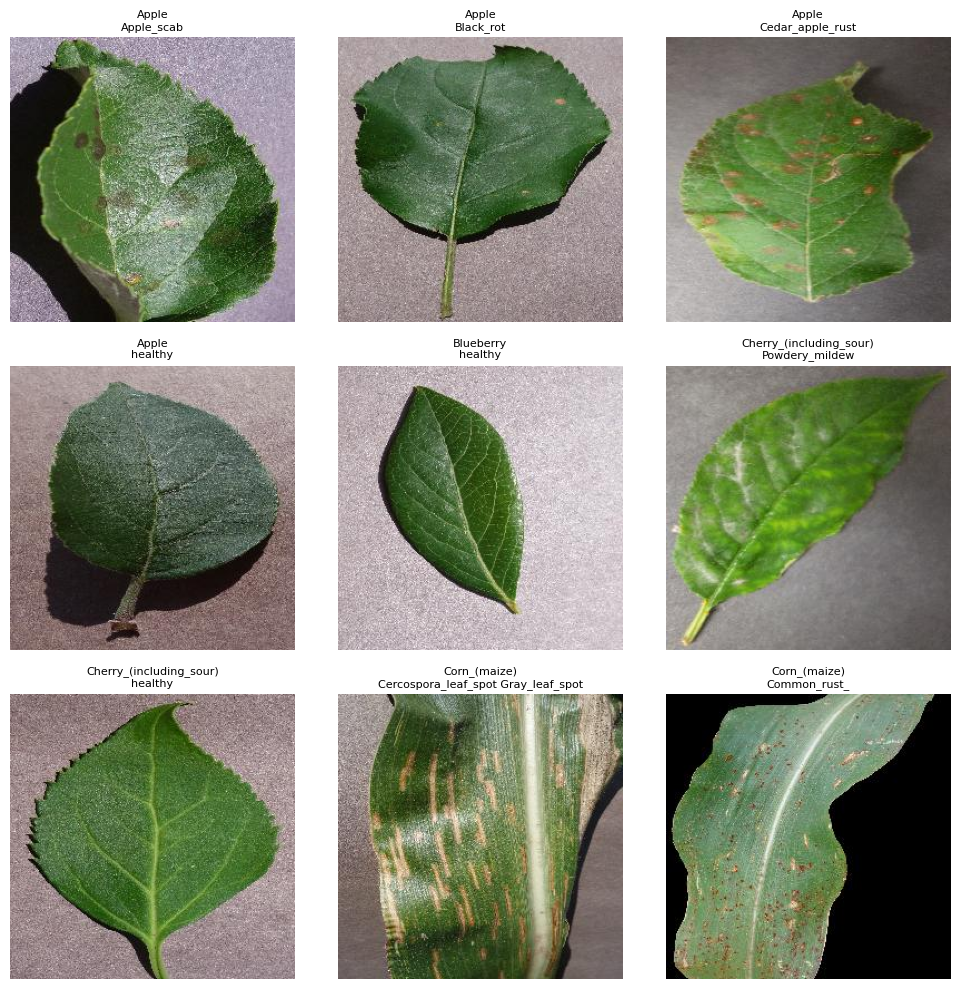

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
sample_classes = classes[:9]

for ax, cls in zip(axes.flatten(), sample_classes):
    cls_path = os.path.join(dataset_path, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    ax.imshow(img)
    ax.set_title(cls.replace("___", "\n").replace("__", "\n"), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#training generator with augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,          #normalize 0-255 → 0.0-1.0
    rotation_range=20,       #randomly rotate images up to 20 degrees
    horizontal_flip=True,    #randomly flip images left-right
    zoom_range=0.2,          #randomly zoom in/out by 20%
    width_shift_range=0.2,   #randomly shift horizontally
    height_shift_range=0.2,  #randomly shift vertically
    validation_split=0.2     #80/20 split
)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,     #resize all images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='categorical', #38 classes = categorical (not binary)
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Class indices sample: {list(train_data.class_indices.items())[:5]}")

Training batches: 1358
Validation batches: 340
Class indices sample: [('Apple___Apple_scab', 0), ('Apple___Black_rot', 1), ('Apple___Cedar_apple_rust', 2), ('Apple___healthy', 3), ('Blueberry___healthy', 4)]


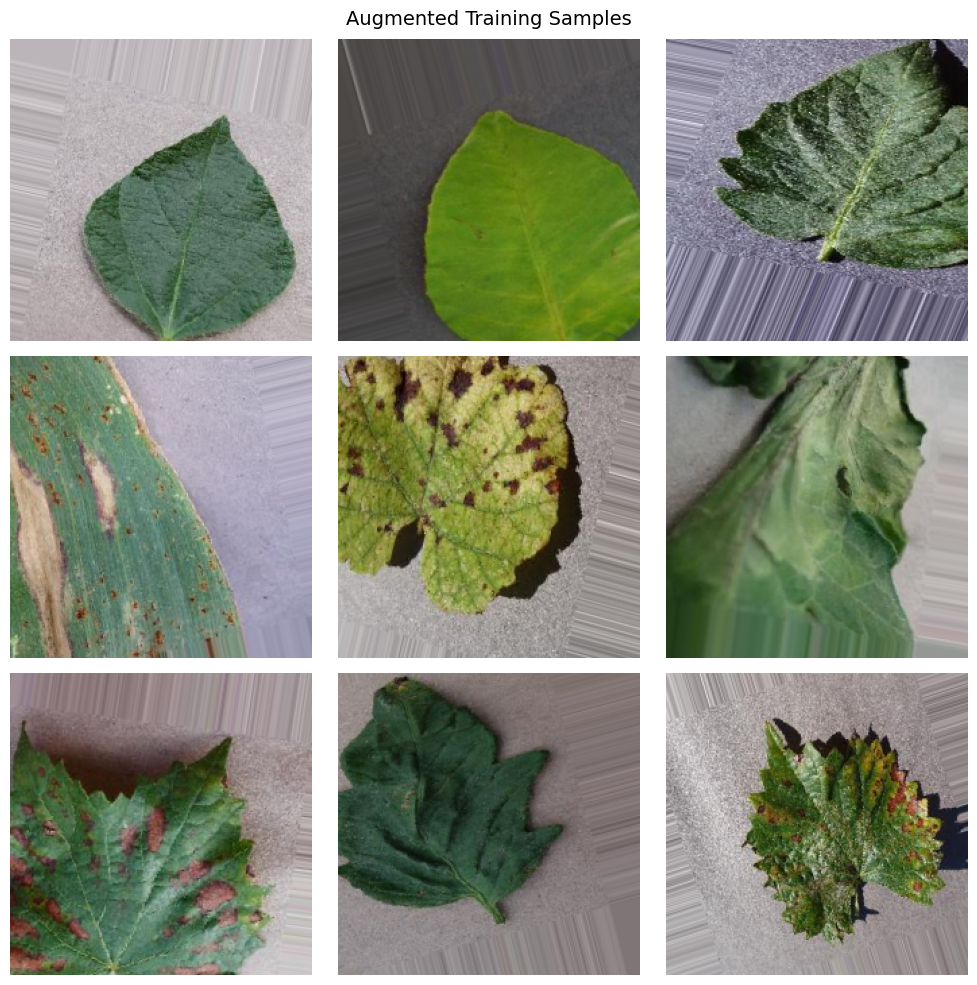

In [ ]:
#grab a batch
sample_images, sample_labels = next(train_data)

#plot 9 images from the batch
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, img in zip(axes.flatten(), sample_images[:9]):
    ax.imshow(img)  #already normalized so it displays fine
    ax.axis("off")

plt.suptitle("Augmented Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

NUM_CLASSES = len(classes)

#load MobileNetV2 pretrained on ImageNet, without the top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

#freeze the base model — we only train the new head first
base_model.trainable = False

#add a custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1049s 755ms/step - accuracy: 0.8110 - loss: 0.6279 - val_accuracy: 0.9141 - val_loss: 0.2672
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 792s 583ms/step - accuracy: 0.8887 - loss: 0.3380 - val_accuracy: 0.9199 - val_loss: 0.2333
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 779s 574ms/step - accuracy: 0.9026 - loss: 0.2938 - val_accuracy: 0.9243 - val_loss: 0.2315
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 784s 577ms/step - accuracy: 0.9103 - loss: 0.2707 - val_accuracy: 0.9315 - val_loss: 0.2003
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 739s 545ms/step - accuracy: 0.9126 - loss: 0.2638 - val_accuracy: 0.9297 - val_loss: 0.2020
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 679s 500ms/step - accuracy: 0.9134 - loss: 0.2517 - val_accuracy: 0.9298 - val_loss: 0.2129
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 673s 496ms/step - accuracy: 0.9206 - loss: 0.2395 - val_accuracy: 0.9333 - val_loss: 0.1949
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 685s 504ms/step - a

In [ ]:
#unfreeze the last ~30 layers of the base model for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 719s 517ms/step - accuracy: 0.8459 - loss: 0.5660 - val_accuracy: 0.9386 - val_loss: 0.1854
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 686s 505ms/step - accuracy: 0.9134 - loss: 0.2656 - val_accuracy: 0.9422 - val_loss: 0.1647
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 702s 517ms/step - accuracy: 0.9288 - loss: 0.2148 - val_accuracy: 0.9528 - val_loss: 0.1437
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 731s 538ms/step - accuracy: 0.9387 - loss: 0.1820 - val_accuracy: 0.9540 - val_loss: 0.1319
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 796s 586ms/step - accuracy: 0.9451 - loss: 0.1623 - val_accuracy: 0.9613 - val_loss: 0.1155


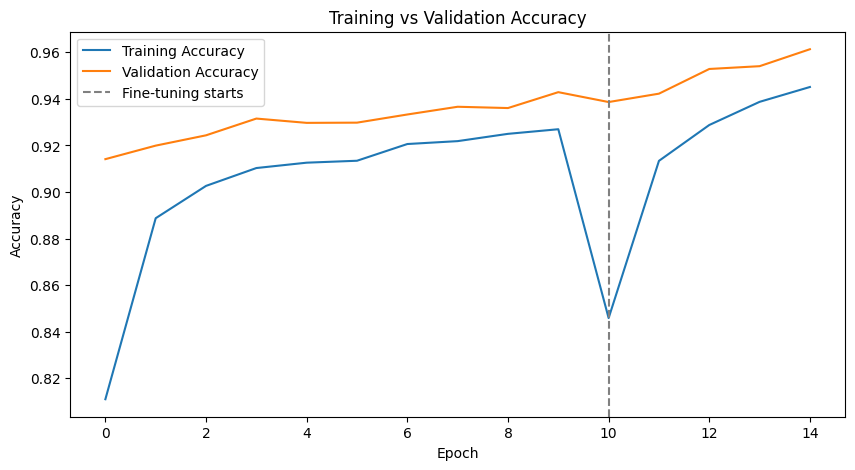

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy']), color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
model.save('plant_disease_model.keras')

import json
with open('class_indices.json', 'w') as f:
    json.dump(train_data.class_indices, f)

print("Saved model and class indices.")

Saved model and class indices.
